In [1]:
import csv
import matplotlib.pyplot as plt
from argparse import Namespace
from collections import defaultdict
import numpy as np


In [2]:
def load_roi_log(roi_log_file):
    with open(roi_log_file, "r") as f:
        reader = csv.reader(f, delimiter='\t')
        raw = list(reader)
        header = raw[0]
        del raw[0]
        roi_logs = []
        for line in raw:
            roi_log = {}
            for i, col in enumerate(line):
                roi_log[header[i]] = col
            roi_logs.append(Namespace(**roi_log))
    return roi_logs

def load_exec_log(exec_log_file):
    with open(exec_log_file, "r") as f:
        reader = csv.reader(f, delimiter='\t')
        raw = list(reader)
        header = raw[0]
        del raw[0]
        exec_logs = []
        for line in raw:
            exec_log = {}
            for i, col in enumerate(line):
                exec_log[header[i]] = col
            exec_logs.append(Namespace(**exec_log))
    return exec_logs

In [3]:
def get_frame_interval_mapping(exec_log):
    '''
    Arguments
        exec_log

    Returns
        frame_index_to_id: Dict[(frame_index, interval_id)]
    '''
    frame_group = defaultdict(list)
    frame_group_check = defaultdict(list)
    for el in exec_log:
        frame_group[el.mixingStartTime].append(el.frameIndex)
        frame_group_check[el.mixingEndTime].append(el.frameIndex)

    for key, frame_indices in frame_group.items():
        frame_group[key] = (list(map(int, frame_indices)))
    for key, frame_indices in frame_group_check.items():
        frame_group_check[key] = (list(map(int, frame_indices)))
    assert (sorted(frame_group.values(), key=lambda x:x[0]) ==sorted(frame_group_check.values(), key=lambda x:x[0]))

    frame_index_to_interval_id = {
        frame_index: i
        for i, (time, frame_indices) in enumerate(frame_group.items())
        for frame_index in frame_indices
    }
    return frame_index_to_interval_id

def get_values_from_roi_log(target_roi_id, roi_log, frame_index_to_id, scale=False):
    '''
    Arguments
        target_roi_id: id of the ROI to get observe
        roi_log
        frame_index_to_id: Dict[(frame_index, interval_id)]
        scale: whether to use scale or size
    
    Returns
        (x, y, boundary):
            x: List[frame_index]
            y: List[size or scale]
            boundary : List[frame_index] for boundaries btn. scheduling intervals
    '''
    x = []
    y = []
    for rl in roi_log:
        if int(rl.id) == target_roi_id:
            x.append(int(rl.frameIndex))
            if scale:
                y.append(float(rl.targetSize) / float(rl.maxEdgeLength))
            else:
                y.append(float(rl.targetSize))
    x = np.array(x)
    assert all(np.diff(x) == 1)

    group = np.array([frame_index_to_id[fi] for fi in x])

    # TODO: test this boundary logic for multi stream setting
    boundary = [
        i
        for i, g in enumerate(group)
        if i != 0 and i != len(group)-1 and g == 0 and group[i-1] != group[i+1]
    ]

    return (x, y, boundary)


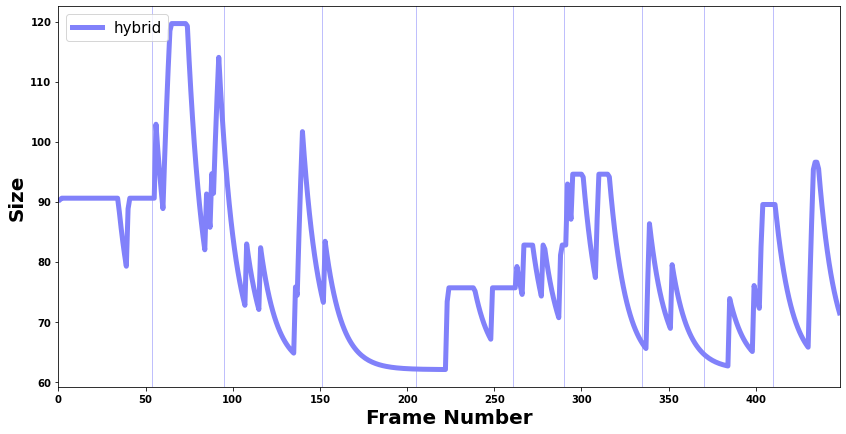

In [4]:

# CONFIG
use_scale = False
target_roi_id = 0

# Load ROI logs
roi_log = load_roi_log("./a1be1c/roi_a1be1c.csv")
exec_log = load_exec_log("./a1be1c/exec_a1be1c.csv")

# group frames to mixing intervals
frame_index_to_id = get_frame_interval_mapping(exec_log=exec_log)

x_y_label_list = []
# extract data of target roi
x, y, boundary = get_values_from_roi_log(
    target_roi_id=target_roi_id,
    roi_log=roi_log,
    frame_index_to_id=frame_index_to_id,
    scale=use_scale
)
x_y_label_list.append((x,y,'hybrid'))

# also repeat those procedures for csvs from predictive setting & reactive probing setting
# and collect them into x_y_label_list

# Draw all graphs
colors = ["#8181FA", "#7FF87D", "#FBBB7B", "#F97B7C"]
plt.subplots(1, figsize=(14,7))
plt.xlabel('Frame Number', fontsize=20, fontweight='bold')
plt.ylabel("Scale" if use_scale else "Size", fontsize=20, fontweight='bold')
plt.xticks(weight = 'bold')
plt.yticks(weight = 'bold')

for i, (x, y, label) in enumerate(x_y_label_list):
    plt.plot(x,y, linewidth=5, linestyle='-',label=label, color=colors[i])
    for b in boundary:
        plt.axvline(x = b, alpha=0.5, linewidth=1, color = colors[i])


plt.xlim(0, (max([max(x) for x, _, _ in x_y_label_list])))
plt.legend(loc='upper left', fontsize=15)
plt.show()